# Customer Churn and Retention Analysis

## Project Objective

The objective of this project is to analyze customer churn patterns for a telecom company and identify the key factors that influence customer retention. The analysis focuses on understanding which customer groups are more likely to leave, what business drivers are associated with churn, and what recommendations can help reduce customer loss.

## Business Problem

Customer churn occurs when customers stop using a company's service. High churn can reduce revenue, increase customer acquisition costs, and weaken long-term business growth. By analyzing churn patterns, the company can identify at-risk customer segments and design better retention strategies.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# Show first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape


(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
df = df.dropna(subset=["TotalCharges"])

In [11]:
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   str    
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [15]:
df.shape

(7032, 21)

## Churn Rate Analysis

This section analyzes the overall customer churn rate. Churn rate shows the percentage of customers who left the company. Understanding the overall churn rate gives a baseline for evaluating the seriousness of customer loss.

In [16]:
# Count churned and retained customers
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [17]:
# Churn percentage
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

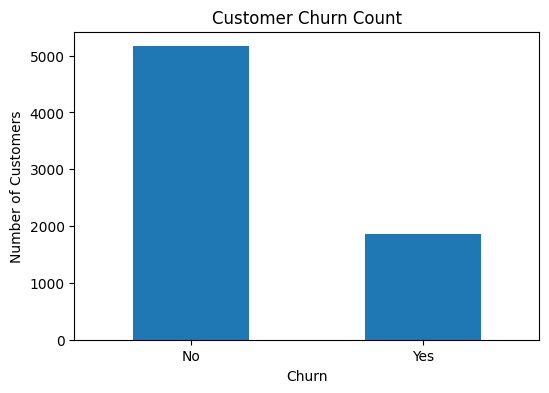

In [18]:
# Churn count visualization
plt.figure(figsize=(6, 4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Count")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.savefig("../images/churn_count.png", bbox_inches="tight")
plt.show()

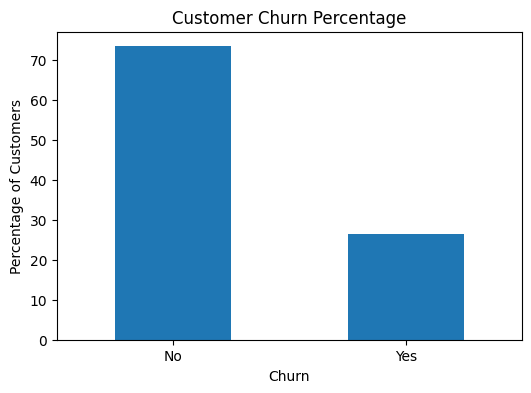

In [19]:
# Churn percentage visualization
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))

churn_percentage.plot(kind="bar")

plt.title("Customer Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

plt.savefig("../images/churn_percentage.png", bbox_inches="tight")
plt.show()

### Key Finding

The overall churn rate is 26.58%, meaning around one out of every four customers left the company. This is a significant churn level because losing existing customers can reduce recurring revenue and increase the need for expensive customer acquisition. The next step is to identify which customer groups are more likely to churn.

## Churn by Contract Type

This section analyzes whether contract type is related to customer churn. Contract length is important because customers on shorter contracts may have more flexibility to leave, while customers on longer contracts may be more committed to staying.

In [20]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [21]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [22]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


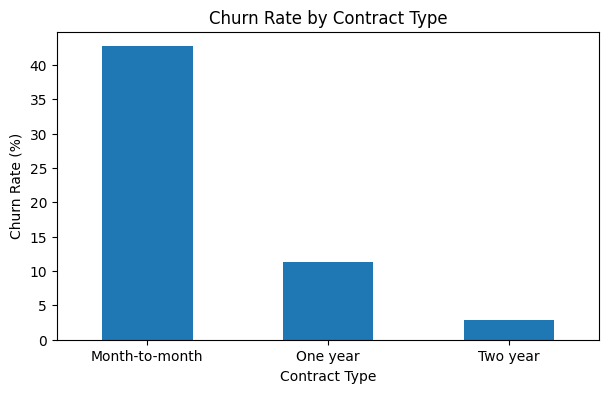

In [23]:
contract_churn["Yes"].sort_values(ascending=False).plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../images/churn_by_contract.png", bbox_inches="tight")
plt.show()

### Key Finding

Contract type has a strong relationship with customer churn. Month-to-month customers have the highest churn rate at 42.71%, while one-year contract customers churn at 11.28% and two-year contract customers churn at only 2.85%. This shows that customers with shorter contract commitments are much more likely to leave. The company should prioritize month-to-month customers for retention campaigns, loyalty offers, and contract upgrade incentives.

## Churn by Customer Tenure

This section analyzes whether customer tenure is related to churn. Tenure shows how long a customer has stayed with the company. This is important because newer customers may be less loyal and more likely to leave compared to long-term customers.

In [24]:
# Average tenure by churn status
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [25]:
# Create tenure groups
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 24:
        return "13-24 months"
    elif tenure <= 48:
        return "25-48 months"
    else:
        return "49+ months"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

df["TenureGroup"].value_counts()

TenureGroup
49+ months      2239
0-12 months     2175
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64

In [26]:
# Churn percentage by tenure group
tenure_churn = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


In [27]:
# Reorder tenure groups
tenure_order = ["0-12 months", "13-24 months", "25-48 months", "49+ months"]

tenure_churn = tenure_churn.loc[tenure_order]

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


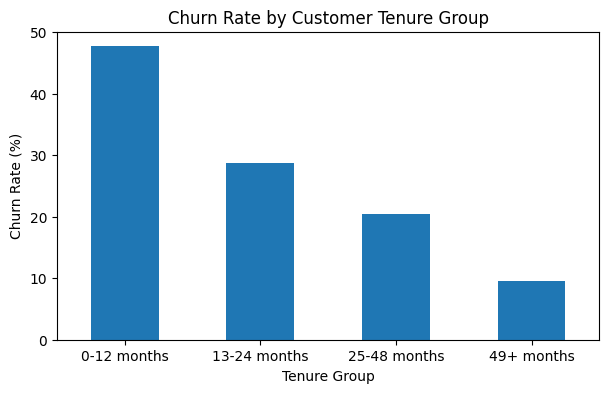

In [28]:
# Churn rate by tenure group visualization
tenure_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Customer Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../images/churn_by_tenure.png", bbox_inches="tight")
plt.show()

### Key Finding

Customer tenure has a strong relationship with churn. Customers in their first 12 months have the highest churn rate at 47.68%, while customers with 49+ months of tenure have a much lower churn rate of 9.51%. This shows that newer customers are much more likely to leave. The company should focus on improving onboarding, early customer support, and first-year retention campaigns.

## Churn by Monthly Charges

This section analyzes whether monthly billing amount is related to churn. Monthly charges are important because customers paying higher prices may be more sensitive to service quality, pricing fairness, or competitor offers.

In [29]:
# Average monthly charges by churn status
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [30]:
# Create monthly charge groups
def charge_group(charge):
    if charge <= 35:
        return "Low"
    elif charge <= 70:
        return "Medium"
    elif charge <= 90:
        return "High"
    else:
        return "Very High"

df["MonthlyChargeGroup"] = df["MonthlyCharges"].apply(charge_group)

df["MonthlyChargeGroup"].value_counts()

MonthlyChargeGroup
High         1842
Very High    1739
Low          1729
Medium       1722
Name: count, dtype: int64

In [31]:
# Churn percentage by monthly charge group
charge_churn = pd.crosstab(df["MonthlyChargeGroup"], df["Churn"], normalize="index") * 100

charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
High,62.160695,37.839305
Low,89.068826,10.931174
Medium,76.016260,23.983740
Very High,67.222542,32.777458


In [33]:
# Reorder monthly charge groups
charge_order = ["Low", "Medium", "High", "Very High"]

charge_churn = charge_churn.loc[charge_order]

charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low,89.068826,10.931174
Medium,76.016260,23.983740
High,62.160695,37.839305
Very High,67.222542,32.777458


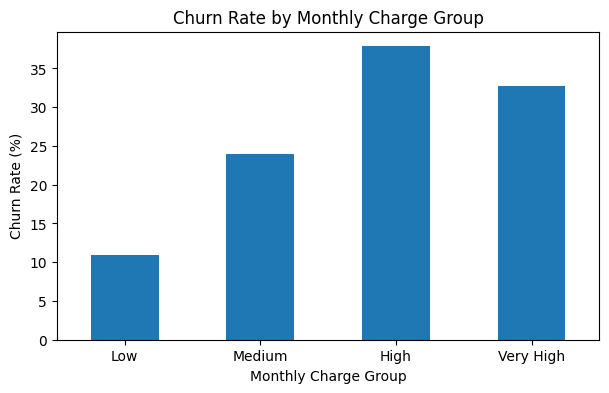

In [34]:
# Churn rate by monthly charge group visualization
charge_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../images/churn_by_monthly_charges.png", bbox_inches="tight")
plt.show()

### Key Finding

Monthly charges are related to churn. Customers in the high monthly charge group have the highest churn rate at 37.84%, followed by the very high charge group at 32.78%. Low-charge customers have the lowest churn rate at 10.93%. This suggests that customers paying higher monthly bills may be more sensitive to price, service quality, or perceived value. The company should monitor high-bill customers and offer targeted retention discounts, bundled benefits, or service improvements.

## Churn by Payment Method

This section analyzes whether payment method is related to customer churn. Payment method can reveal differences in customer behavior, convenience, and commitment. Some payment methods may be linked with higher churn because they are easier to cancel or are used by less committed customers.

In [36]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [37]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


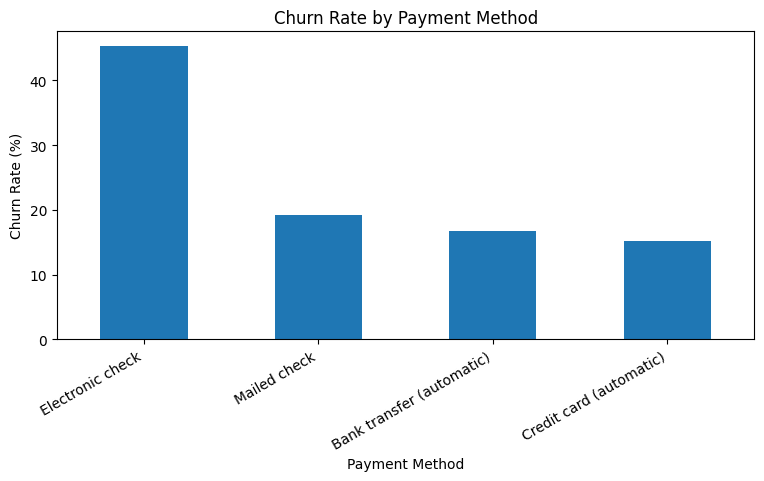

In [38]:
payment_churn["Yes"].sort_values(ascending=False).plot(kind="bar", figsize=(9, 4))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.savefig("../images/churn_by_payment_method.png", bbox_inches="tight")
plt.show()

### Key Finding

Payment method shows a strong relationship with churn. Customers using electronic checks have the highest churn rate at 45.29%, which is much higher than customers using automatic payment methods. Credit card automatic and bank transfer automatic customers have the lowest churn rates. This suggests that customers using automatic payments may be more stable and committed, while electronic check users should be prioritized for retention campaigns.

## Churn by Internet Service Type

This section analyzes whether internet service type is related to customer churn. Internet service is a major part of the customer experience, so differences in churn across service types may reveal service quality, pricing, or customer satisfaction issues.

In [39]:
df["InternetService"].value_counts()


InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [40]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

internet_churn


Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


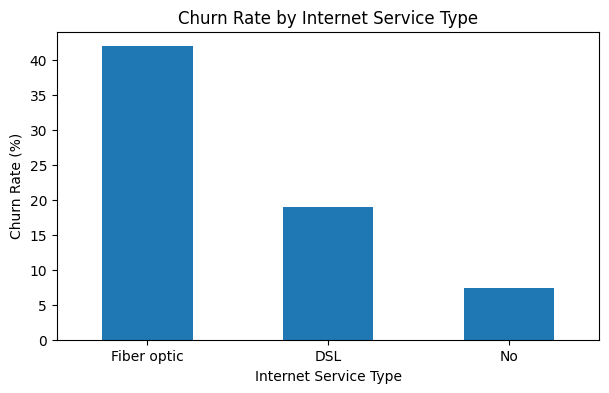

In [41]:
internet_churn["Yes"].sort_values(ascending=False).plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../images/churn_by_internet_service.png", bbox_inches="tight")
plt.show()

### Key Finding

Internet service type is strongly related to churn. Fiber optic customers have the highest churn rate at 41.89%, compared to 19.00% for DSL customers and only 7.43% for customers with no internet service. This suggests that fiber optic customers may be more sensitive to pricing, service quality, or competitor offers. The company should investigate this segment more closely and consider targeted support, service improvements, or better value bundles.

## High-Risk Customer Segment Analysis

After analyzing individual churn drivers, this section combines the strongest risk factors to identify high-risk customer segments. This helps the business move from general churn analysis to targeted retention planning.

In [42]:
# Create risk flags based on key churn drivers
df["MonthToMonthFlag"] = df["Contract"].apply(lambda x: 1 if x == "Month-to-month" else 0)
df["NewCustomerFlag"] = df["tenure"].apply(lambda x: 1 if x <= 12 else 0)
df["ElectronicCheckFlag"] = df["PaymentMethod"].apply(lambda x: 1 if x == "Electronic check" else 0)
df["FiberOpticFlag"] = df["InternetService"].apply(lambda x: 1 if x == "Fiber optic" else 0)
df["HighChargeFlag"] = df["MonthlyChargeGroup"].apply(lambda x: 1 if x in ["High", "Very High"] else 0)

In [43]:
# Calculate total risk score
df["RiskScore"] = (
    df["MonthToMonthFlag"] +
    df["NewCustomerFlag"] +
    df["ElectronicCheckFlag"] +
    df["FiberOpticFlag"] +
    df["HighChargeFlag"]
)

df["RiskScore"].value_counts().sort_index()

RiskScore
0    1364
1    1150
2    1757
3    1187
4    1003
5     571
Name: count, dtype: int64

In [44]:
# Churn rate by risk score
risk_churn = pd.crosstab(df["RiskScore"], df["Churn"], normalize="index") * 100

risk_churn

Churn,No,Yes
RiskScore,,
0,97.727273,2.272727
1,91.304348,8.695652
2,79.510529,20.489471
3,65.627633,34.372367
4,43.469591,56.530409
5,29.422067,70.577933


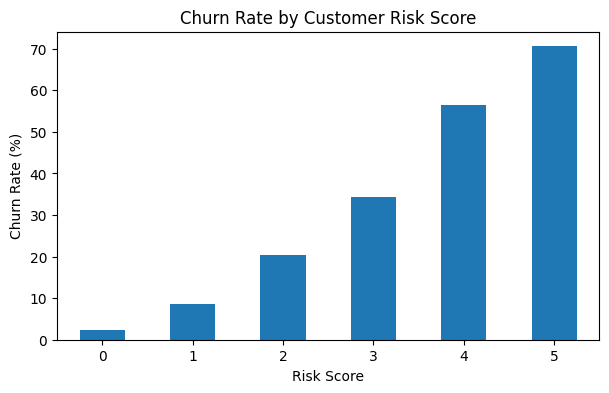

In [45]:
# Churn rate by risk score visualization
risk_churn["Yes"].plot(kind="bar", figsize=(7, 4))

plt.title("Churn Rate by Customer Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.savefig("../images/churn_by_risk_score.png", bbox_inches="tight")
plt.show()

### Key Finding

The risk score analysis shows a clear increase in churn as customers accumulate more risk factors. Customers with a risk score of 0 have only a 2.27% churn rate, while customers with a risk score of 5 have a churn rate of 70.58%. This means customers who are new, on month-to-month contracts, using electronic checks, subscribed to fiber optic internet, and paying higher monthly charges are the most likely to leave. This risk score can help the company prioritize retention efforts more effectively.

## Business Recommendations

Based on the churn analysis, several customer groups show a higher risk of leaving. The company should focus on targeted retention strategies rather than applying the same approach to all customers.

### 1. Prioritize Month-to-Month Customers

Customers with month-to-month contracts have the highest churn rate at 42.71%. The company should target these customers with contract upgrade incentives, loyalty discounts, or limited-time offers to encourage them to move to one-year or two-year contracts.

### 2. Improve First-Year Customer Retention

Customers in their first 12 months have a churn rate of 47.68%, which is much higher than long-term customers. The company should improve onboarding, provide early customer support, and send follow-up messages during the first few months to ensure new customers are satisfied.

### 3. Monitor High Monthly Charge Customers

Customers with high monthly charges show higher churn rates than low-charge customers. The company should review whether these customers feel they are receiving enough value for the price they pay. Retention offers, bundled packages, or service quality improvements may help reduce churn in this group.

### 4. Investigate Fiber Optic Customer Churn

Fiber optic customers have a churn rate of 41.89%, which is much higher than DSL customers. The company should investigate whether this is caused by pricing, service reliability, competition, or unmet customer expectations.

### 5. Encourage Stable Payment Methods

Customers using electronic checks have the highest churn rate at 45.29%. The company could encourage these customers to switch to automatic payment methods such as credit card or bank transfer by offering small discounts or convenience benefits.

### 6. Use Risk Scores for Targeted Retention

The risk score analysis shows that customers with more risk factors are much more likely to churn. Customers with a risk score of 4 or 5 should be treated as high-priority retention targets. The company can use this score to identify at-risk customers before they leave.

## Conclusion

This project analyzed customer churn patterns for a telecom company using customer demographics, billing information, contract details, service usage, and payment methods. The overall churn rate was 26.58%, meaning roughly one in four customers left the company.

The analysis found that churn is strongly linked with contract type, tenure, monthly charges, payment method, and internet service type. Month-to-month customers, newer customers, electronic check users, fiber optic customers, and high-charge customers showed higher churn rates.

The high-risk customer score provided a practical way to combine these factors and identify customers most likely to leave. This allows the business to move from general analysis to targeted retention planning. By focusing on high-risk segments, the company can improve customer retention, reduce revenue loss, and make better use of marketing and customer support resources.